In [1]:


import pandas as pd
import torch, random
import numpy as np, sys, os
sys.path.append(os.path.abspath(os.path.join('/home/khatiwada/dust')))
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

import utilities as utl
from transformers import RobertaTokenizerFast, RobertaModel
from model_classes import BertClassifier
from torch.nn.parallel import DataParallel




In [2]:
# ==== Set seeds ====
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

# ==== Device ====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==== Load model and tokenizer ====
model_path = r'../out_model/tus_finetune_roberta/checkpoints/best-checkpoint.pt'
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")
base_model = RobertaModel.from_pretrained('roberta-base')
model = BertClassifier(base_model, num_labels=2, hidden_size=768, output_size=768)
model = DataParallel(model, device_ids=[0, 1, 2, 3])
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()


/home/khatiwada/dust/env/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DataParallel(
  (module): BertClassifier(
    (bert): RobertaModel(
      (embeddings): RobertaEmbeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
        (token_type_embeddings): Embedding(1, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): RobertaEncoder(
        (layer): ModuleList(
          (0-11): 12 x RobertaLayer(
            (attention): RobertaAttention(
              (self): RobertaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): RobertaSelfOutput(
                (dense): Linear(in_features=76

In [3]:
# ==== Encode with batch processing ====
def encode_finetuned(sentences, model, tokenizer, batch_size=64):
    embeddings = []
    for i in tqdm(range(0, len(sentences), batch_size), desc="Encoding batches", unit="batch"):
        batch = sentences[i:i+batch_size]
        encodings = tokenizer(batch, add_special_tokens=True, truncation=True, padding=True, return_tensors='pt')
        input_ids = encodings['input_ids'].to(device)
        attention_mask = encodings['attention_mask'].to(device)
        with torch.no_grad():
            batch_embeddings = model(input_ids, attention_mask)
        embeddings.append(batch_embeddings.cpu().numpy())
    return np.vstack(embeddings)

# ==== Shuffle column function ====
def shuffle_columns(serialized_text):
    chunks = serialized_text.split("COL")[1:]  # Remove the initial empty split
    col_val_pairs = ["COL " + chunk.strip() for chunk in chunks]
    random.shuffle(col_val_pairs)
    return " ".join(col_val_pairs)


In [4]:
# ==== Load serialized data ====
data = pd.read_csv("/home/khatiwada/dust/data/finetune_data/tus_finetune/test", sep="\t", header=None, names=["row1", "row2", "label"])
all_rows = data["row1"].tolist() + data["row2"].tolist()

# ==== Generate shuffled versions ====
original_texts = all_rows #[:5000]
shuffled_texts = [shuffle_columns(row) for row in original_texts]




In [5]:
# ==== Encode all texts ====
print("Encoding original and shuffled texts...")
all_embeddings = encode_finetuned(original_texts + shuffled_texts, model, tokenizer, batch_size=512)
original_embeds = all_embeddings[:len(original_texts)]
shuffled_embeds = all_embeddings[len(original_texts):]


Encoding original and shuffled texts...


Encoding batches: 100%|██████████| 71/71 [22:03<00:00, 18.65s/batch]


In [6]:
# ==== Compute cosine similarities ====
print("Computing cosine similarities...")
cosine_scores = []
for orig, shuf in tqdm(zip(original_embeds, shuffled_embeds), desc="Calculating cosine similarities", total=len(original_embeds)):
    sim = cosine_similarity([orig], [shuf])[0][0]
    cosine_scores.append(sim)


Computing cosine similarities...


Calculating cosine similarities: 100%|██████████| 18000/18000 [00:08<00:00, 2086.96it/s]



📊 Cosine Similarity Statistics:
Average:            0.98
Standard Deviation: 0.04
Minimum:            0.41
Median:            1.00
Maximum:            1.00
10th Percentile:    0.96
90th Percentile:    1.00


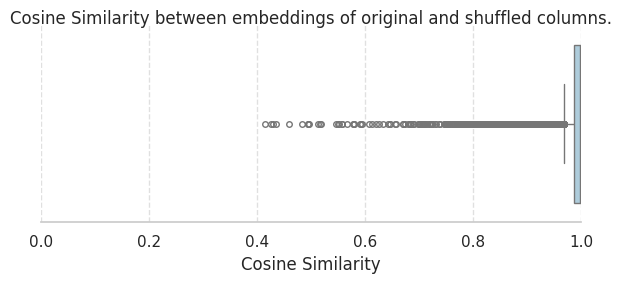

In [7]:


# Ensure cosine_scores is a NumPy array
cosine_scores = np.array(cosine_scores)

# ==== Stats ====
avg_score = cosine_scores.mean()
std_score = cosine_scores.std()
min_score = cosine_scores.min()
max_score = cosine_scores.max()
p10 = np.percentile(cosine_scores, 10)
p90 = np.percentile(cosine_scores, 90)
median_score = np.median(cosine_scores)

print(f"\n📊 Cosine Similarity Statistics:")
print(f"Average:            {avg_score:.2f}")
print(f"Standard Deviation: {std_score:.2f}")
print(f"Minimum:            {min_score:.2f}")
print(f"Median:            {median_score:.2f}")
print(f"Maximum:            {max_score:.2f}")
print(f"10th Percentile:    {p10:.2f}")
print(f"90th Percentile:    {p90:.2f}")

# Stats for plotting
stat_lines = {
    "Mean": (avg_score, 'tab:blue', '-'),
    "Median": (median_score, 'tab:green', '--'),
    "10th %ile": (p10, 'tab:orange', '-.'),
    "90th %ile": (p90, 'tab:purple', ':'),
    "Min": (min_score, 'black', (0, (3, 1, 1, 1))),
    "Max": (max_score, 'gray', (0, (5, 5)))
}

sns.set(style="whitegrid", font_scale=1)

# ==== Box Plot ====
plt.figure(figsize=(6, 3))
ax = sns.boxplot(x=cosine_scores, color="#a6cee3", linewidth=1, fliersize=4)

# for label, (value, color, linestyle) in stat_lines.items():
#     ax.axvline(value, color=color, linestyle=linestyle, linewidth=2)

ax.set_title("Cosine Similarity between embeddings of original and shuffled columns.", fontsize=12, pad=1)
ax.set_xlabel("Cosine Similarity", fontsize=12)
ax.set_xlim(0, 1.0)
ax.set_yticks([])
ax.grid(True, linestyle='--', alpha=0.6)
sns.despine(left=True)
plt.tight_layout()
# plt.savefig("plots/test_set_cosine_similarity_boxplot.pdf") 
plt.show()
plt.close()


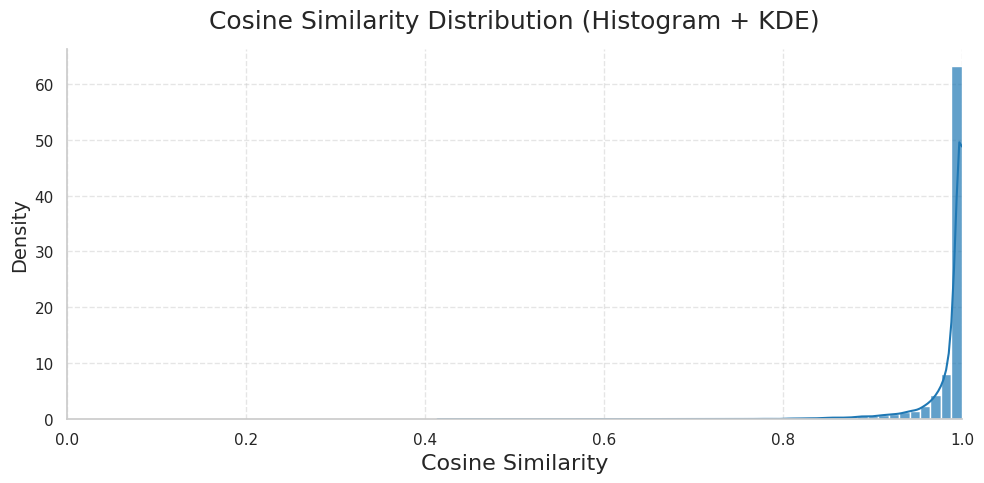

In [8]:
# ==== Histogram + KDE Plot ====
plt.figure(figsize=(10, 5))
hist_ax = sns.histplot(cosine_scores, bins=50, kde=True, color="#1f78b4", edgecolor='white', alpha=0.7, stat="density")

# for label, (value, color, linestyle) in stat_lines.items():
#     hist_ax.axvline(value, color=color, linestyle=linestyle, linewidth=2)

hist_ax.set_title("Cosine Similarity Distribution (Histogram + KDE)", fontsize=18, pad=15)
hist_ax.set_xlabel("Cosine Similarity", fontsize=16)
hist_ax.set_ylabel("Density", fontsize=14)
hist_ax.set_xlim(0, 1.0)
hist_ax.grid(True, linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()
